In [1]:
import arff
import pandas as pd
import numpy as np

# Load the ARFF file
with open('../dataset/Training Dataset.arff', 'r') as f:
    dataset = arff.load(f)

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (11055, 31)

Columns: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

Data types:
having_IP_Address              str
URL_Length                     str
Shortining_Service             str
having_At_Symbol               str
double_slash_redirecting       str
Prefix_Suffix                  str
having_Sub_Domain              str
SSLfinal_State                 str
Domain_registeration_length    str
Favicon                        str
port                           str
HTTPS_token                    str
Request_URL      

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [2]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric)

print("Data types after conversion:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nTarget distribution (Result column):")
print(df['Result'].value_counts())

print("\nTarget distribution (%):")
print(df['Result'].value_counts(normalize=True) * 100)

Data types after conversion:
int64    31
Name: count, dtype: int64

Missing values:
0

Target distribution (Result column):
Result
 1    6157
-1    4898
Name: count, dtype: int64

Target distribution (%):
Result
 1    55.694256
-1    44.305744
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt

# Separate features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Correlation of each feature with the target
correlations = X.corrwith(y).sort_values(ascending=False)

print("Feature correlations with Result (most to least):")
print(correlations)

# Plot it
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['green' if c > 0 else 'red' for c in correlations])
plt.title('Feature Correlation with Target (Phishing vs Legitimate)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

Feature correlations with Result (most to least):
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
URL_Length                     0.057430
having_At_Symbol               0.052948
on_mouseover                   0.041838
port                           0.036419
Links_pointing_to_page         0.032574
Submitting_to_email            0.018249
RightClick                     0.012653
popUpWidnow                    0.000086
Favicon                       -0.000280
Iframe                        

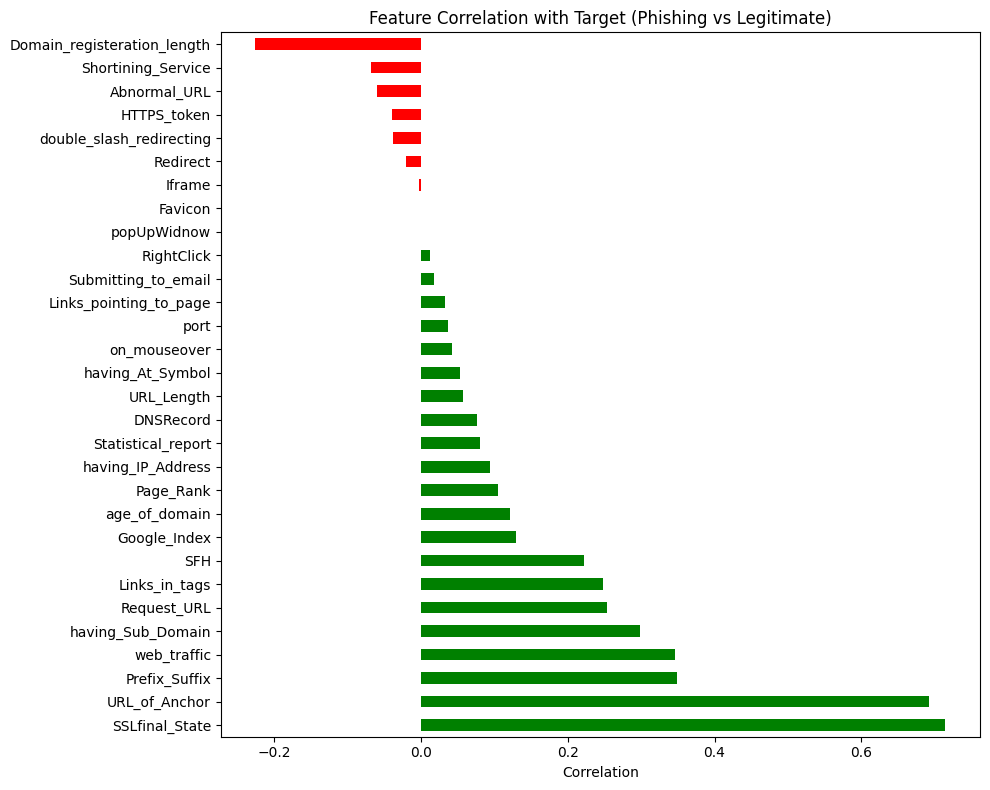

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt

# Separate features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Correlation of each feature with the target
correlations = X.corrwith(y).sort_values(ascending=False)

print("Feature correlations with Result (most to least):")
print(correlations)

# Plot it
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['green' if c > 0 else 'red' for c in correlations])
plt.title('Feature Correlation with Target (Phishing vs Legitimate)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split data into features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set size: (8844, 30)
Testing set size: (2211, 30)

Training target distribution:
Result
 1    4926
-1    3918
Name: count, dtype: int64

Testing target distribution:
Result
 1    1231
-1     980
Name: count, dtype: int64


In [6]:
# Train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=None,        # trees grow until pure
    random_state=42,       # reproducibility
    n_jobs=-1              # use all CPU cores
)

rf_model.fit(X_train, y_train)

print("Model trained successfully!")

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Evaluate
print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legitimate']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Model trained successfully!

Accuracy: 97.42198100407056 %

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.98      0.96      0.97       980
  Legitimate       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Confusion Matrix:
[[ 942   38]
 [  19 1212]]


In [7]:
import joblib
import os

# Create model directory if it doesn't exist
os.makedirs('../model', exist_ok=True)

# Save the trained model
joblib.dump(rf_model, '../model/phishing_detector.pkl')

# Save the feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../model/feature_names.pkl')

print("Model saved to ../model/phishing_detector.pkl")
print("Feature names saved to ../model/feature_names.pkl")
print("\nFeature names:")
print(feature_names)

Model saved to ../model/phishing_detector.pkl
Feature names saved to ../model/feature_names.pkl

Feature names:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


In [8]:
import sys
sys.path.append('../backend')

from feature_extractor import extract_features

# Test on a known legitimate site
url = "https://www.google.com"
print(f"Testing: {url}")
print("Extracting features...\n")

features = extract_features(url)

for feature, value in features.items():
    label = "Legitimate" if value == 1 else ("Suspicious" if value == 0 else "Phishing")
    print(f"{feature:<35} {value:>3}  → {label}")

ImportError: cannot import name 'extract_features' from 'feature_extractor' (C:\Users\i2493\onedrive\documents\code\phishing-detector\notebooks\../backend\feature_extractor.py)

In [9]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location(
    "feature_extractor", 
    "../backend/feature_extractor.py"
)
module = importlib.util.module_from_spec(spec)

try:
    spec.loader.exec_module(module)
    print("File loaded successfully")
except Exception as e:
    print(f"Error: {e}")

File loaded successfully


In [10]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "feature_extractor",
    "../backend/feature_extractor.py"
)
feature_extractor = importlib.util.module_from_spec(spec)
spec.loader.exec_module(feature_extractor)

extract_features = feature_extractor.extract_features

# Test on a known legitimate site
url = "https://www.google.com"
print(f"Testing: {url}")
print("Extracting features...\n")

features = extract_features(url)

for feature, value in features.items():
    label = "Legitimate" if value == 1 else ("Suspicious" if value == 0 else "Phishing")
    print(f"{feature:<35} {value:>3}  → {label}")

AttributeError: module 'feature_extractor' has no attribute 'extract_features'

In [11]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "feature_extractor",
    "../backend/feature_extractor.py"
)
feature_extractor = importlib.util.module_from_spec(spec)
spec.loader.exec_module(feature_extractor)

extract_features = feature_extractor.extract_features

# Test on a known legitimate site
url = "https://www.google.com"
print(f"Testing: {url}")
print("Extracting features...\n")

features = extract_features(url)

for feature, value in features.items():
    label = "Legitimate" if value == 1 else ("Suspicious" if value == 0 else "Phishing")
    print(f"{feature:<35} {value:>3}  → {label}")

Testing: https://www.google.com
Extracting features...

having_IP_Address                     1  → Legitimate
URL_Length                            1  → Legitimate
Shortining_Service                    1  → Legitimate
having_At_Symbol                      1  → Legitimate
double_slash_redirecting              1  → Legitimate
Prefix_Suffix                         1  → Legitimate
having_Sub_Domain                     1  → Legitimate
SSLfinal_State                        0  → Suspicious
Domain_registeration_length           1  → Legitimate
Favicon                               1  → Legitimate
port                                  1  → Legitimate
HTTPS_token                           1  → Legitimate
Request_URL                           1  → Legitimate
URL_of_Anchor                         1  → Legitimate
Links_in_tags                         1  → Legitimate
SFH                                   1  → Legitimate
Submitting_to_email                   1  → Legitimate
Abnormal_URL              

In [12]:
import joblib
import pandas as pd

# Load saved model and feature names
rf_model = joblib.load('../model/phishing_detector.pkl')
feature_names = joblib.load('../model/feature_names.pkl')

# Convert features to dataframe in correct order
feature_vector = pd.DataFrame([features])[feature_names]

# Predict
prediction = rf_model.predict(feature_vector)[0]
probability = rf_model.predict_proba(feature_vector)[0]

print(f"URL: {url}")
print(f"\nPrediction: {'✅ LEGITIMATE' if prediction == 1 else '🚨 PHISHING'}")
print(f"Confidence: {max(probability) * 100:.2f}%")
print(f"\nPhishing probability:   {probability[0] * 100:.2f}%")
print(f"Legitimate probability: {probability[1] * 100:.2f}%")

URL: https://www.google.com

Prediction: ✅ LEGITIMATE
Confidence: 76.00%

Phishing probability:   24.00%
Legitimate probability: 76.00%


In [13]:
# Test on a suspicious URL
test_urls = [
    "http://paypal-security-update.tk/login",
    "http://192.168.1.1/admin/login.php",
]

for test_url in test_urls:
    print(f"\nTesting: {test_url}")
    print("Extracting features...")
    
    try:
        feats = extract_features(test_url)
        feature_vector = pd.DataFrame([feats])[feature_names]
        prediction = rf_model.predict(feature_vector)[0]
        probability = rf_model.predict_proba(feature_vector)[0]
        
        print(f"Prediction: {'✅ LEGITIMATE' if prediction == 1 else '🚨 PHISHING'}")
        print(f"Confidence: {max(probability) * 100:.2f}%")
    except Exception as e:
        print(f"Error: {e}")


Testing: http://paypal-security-update.tk/login
Extracting features...


Error trying to connect to socket: closing socket - timed out
Error trying to connect to socket: closing socket - timed out
Error trying to connect to socket: closing socket - timed out


Prediction: ✅ LEGITIMATE
Confidence: 50.07%

Testing: http://192.168.1.1/admin/login.php
Extracting features...
Prediction: ✅ LEGITIMATE
Confidence: 81.90%


In [14]:
from PIL import Image, ImageDraw
import os

# Create icons directory
os.makedirs('../extension/icons', exist_ok=True)

def create_icon(size):
    # Create a shield icon
    img = Image.new('RGBA', (size, size), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)
    
    # Background circle
    draw.ellipse([2, 2, size-2, size-2], fill=(30, 58, 95, 255))
    
    # Shield shape (simplified as text)
    font_size = int(size * 0.6)
    draw.ellipse([size//4, size//4, 3*size//4, 3*size//4], 
                  fill=(74, 158, 255, 255))
    
    return img

sizes = [16, 48, 128]
for size in sizes:
    icon = create_icon(size)
    path = f'../extension/icons/icon{size}.png'
    icon.save(path)
    print(f"Created icon{size}.png")

print("\nAll icons created successfully")

Created icon16.png
Created icon48.png
Created icon128.png

All icons created successfully


In [15]:
from PIL import Image, ImageDraw, ImageFont
import os

def create_shield_icon(size):
    img = Image.new('RGBA', (size, size), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)
    
    # Dark background circle
    draw.ellipse([0, 0, size-1, size-1], fill=(15, 17, 23, 255))
    
    # Shield body points scaled to size
    s = size
    shield = [
        (s*0.5, s*0.08),   # top center
        (s*0.92, s*0.25),  # top right
        (s*0.92, s*0.55),  # right
        (s*0.5, s*0.92),   # bottom center
        (s*0.08, s*0.55),  # left
        (s*0.08, s*0.25),  # top left
    ]
    
    # Shield fill
    draw.polygon(shield, fill=(30, 58, 95, 255))
    
    # Shield border
    draw.polygon(shield, outline=(74, 158, 255, 255))
    
    # Checkmark for larger icons
    if size >= 48:
        cx, cy = s*0.5, s*0.52
        lw = max(2, size//16)
        draw.line([cx-s*0.18, cy, cx-s*0.02, cy+s*0.18], 
                  fill=(74, 255, 158, 255), width=lw)
        draw.line([cx-s*0.02, cy+s*0.18, cx+s*0.22, cy-s*0.18], 
                  fill=(74, 255, 158, 255), width=lw)
    
    return img

sizes = [16, 48, 128]
for size in sizes:
    icon = create_shield_icon(size)
    path = f'../extension/icons/icon{size}.png'
    icon.save(path)
    print(f"Created icon{size}.png")

print("\nAll icons recreated successfully")

Created icon16.png
Created icon48.png
Created icon128.png

All icons recreated successfully
